# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [7]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

# Khai báo các tham số huấn luyện
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3
DATA_DIR = './data'

# Chọn thiết bị tính toán
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(0)

print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị: {DEVICE}')

PyTorch: 2.13.0+cpu
Thiết bị: cpu


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train = datasets.EMNIST(DATA_DIR, split='letters', train=True, transform=transform, download=True)
test_set = datasets.EMNIST(DATA_DIR, split='letters', train=False, transform=transform, download=True)

# Tách full_train thành train_set (100.000) và val_set (24.800)
train_set, val_set = random_split(full_train, [100000, 24800])

# Tạo DataLoader
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_set), len(val_set), len(test_set))

100000 24800 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


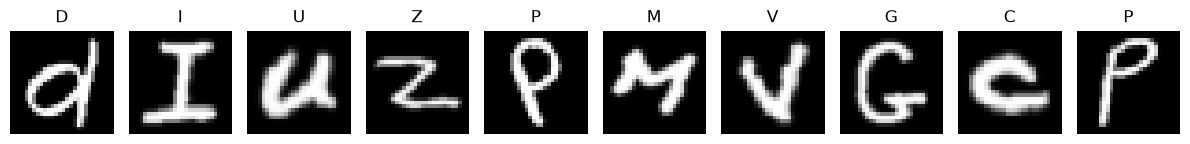

In [9]:
batch_images, batch_labels = next(iter(train_loader))
print('Batch ảnh :', batch_images.shape)
print('Batch nhãn:', batch_labels.shape)

# Vẽ 10 ảnh đầu tiên của batch
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    # Ảnh EMNIST bị xoay ngược chiều kim đồng hồ và lật; transpose đống này để hiển thị đúng hướng
    img = batch_images[i].squeeze().numpy().T
    label_idx = batch_labels[i].item() - 1  # Đưa về dải 0 - 25
    char_label = chr(label_idx + ord('A'))
    
    plt.imshow(img, cmap='gray')
    plt.title(char_label)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [10]:
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 26)
        )

    def forward(self, images):
        return self.net(images)

model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=26, bias=True)
  )
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(DEVICE)
        # EMNIST split='letters' dùng nhãn 1-26, đưa về 0-25 cho CrossEntropyLoss
        labels = (labels - 1).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = (labels - 1).to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [12]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2%}")

Epoch 01/05 | Train Loss: 1.2334 - Train Acc: 66.31% | Val Loss: 0.8672 - Val Acc: 75.40%
Epoch 02/05 | Train Loss: 0.7317 - Train Acc: 79.10% | Val Loss: 0.6606 - Val Acc: 80.79%
Epoch 03/05 | Train Loss: 0.5754 - Train Acc: 83.38% | Val Loss: 0.5511 - Val Acc: 83.79%
Epoch 04/05 | Train Loss: 0.4919 - Train Acc: 85.54% | Val Loss: 0.4891 - Val Acc: 85.48%
Epoch 05/05 | Train Loss: 0.4393 - Train Acc: 86.88% | Val Loss: 0.4566 - Val Acc: 86.24%


## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

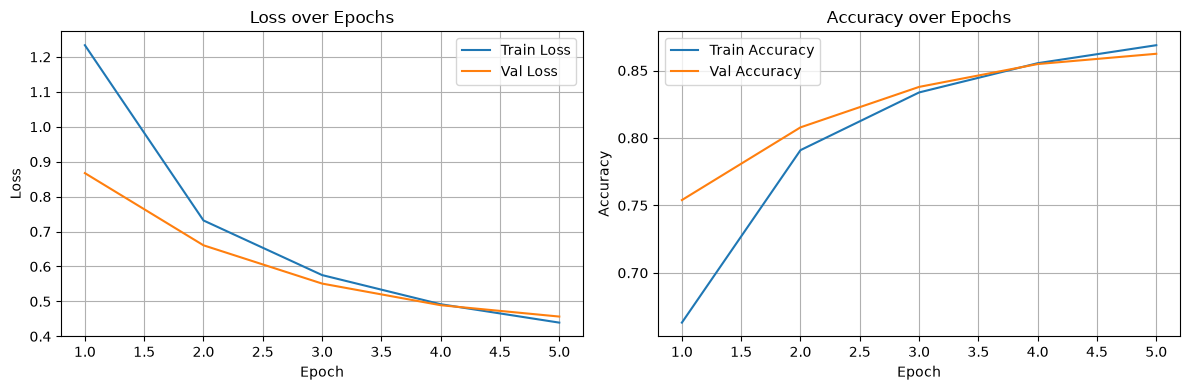

Test loss=0.4646, test accuracy=86.18%


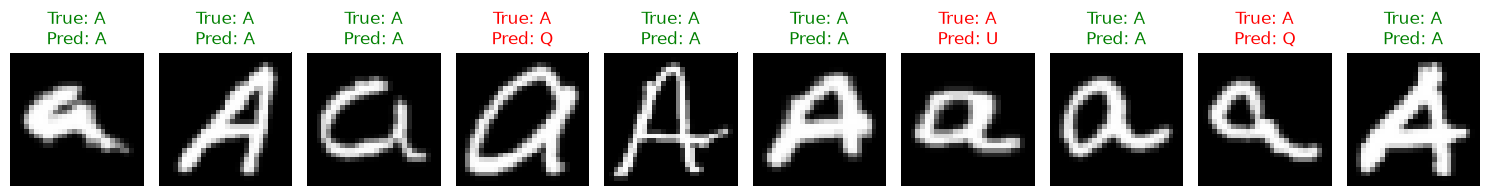

In [13]:
# 1. Vẽ đồ thị Loss và Accuracy theo Epoch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS + 1), train_losses, label='Train Loss')
axes[0].plot(range(1, EPOCHS + 1), val_losses, label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, EPOCHS + 1), train_accuracies, label='Train Accuracy')
axes[1].plot(range(1, EPOCHS + 1), val_accuracies, label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. Đánh giá trên test set
test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f'Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}')

# 3. Trực quan hóa 10 ảnh test cùng nhãn dự đoán vs nhãn thật
model.eval()
test_images, test_labels = next(iter(test_loader))
test_images_dev = test_images.to(DEVICE)
test_labels_dev = (test_labels - 1).to(DEVICE)

with torch.no_grad():
    outputs = model(test_images_dev)
    preds = outputs.argmax(dim=1).cpu()

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    img = test_images[i].squeeze().numpy().T
    true_char = chr((test_labels[i].item() - 1) + ord('A'))
    pred_char = chr(preds[i].item() + ord('A'))

    is_correct = true_char == pred_char
    color = 'green' if is_correct else 'red'

    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_char}\nPred: {pred_char}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

In [14]:
torch.save(model.state_dict(), 'emnist_mlp.pt')
print("Đã lưu thành công mô hình vào file emnist_mlp.pt!")

Đã lưu thành công mô hình vào file emnist_mlp.pt!
